# GridWatch — Notebook 1: Data Exploration
## Exploratory Data Analysis of EAGLE-I Power Outage Data (2014–2025)

**Author:** Jaykumar Patel  
**Affiliation:** MS Data Science, Stevens Institute of Technology | MS IT Project Management (in progress), New England College  
**Dataset:** EAGLE-I (Environment for Analysis of Geo-Located Energy Information), Oak Ridge National Laboratory  
**Coverage:** 9 Northeast US States | 2014–2025 | 89,945 county-days  

---

### Research Questions Addressed in This Notebook
- RQ1: What are the spatial and temporal patterns of major power outages across the Northeast US?
- How do outage rates vary by state, season, and year?
- What is the distribution of outage severity (customers affected)?
- Which states and counties face the highest outage burden?

---

## 1. Setup and Data Loading

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Plot styling — publication quality
plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.color':        '#cccccc',
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
})

PROC_DIR = Path('../data/processed')
FIG_DIR  = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Color palette — consistent throughout
STATE_COLORS = {
    'Maine':         '#dc2626',
    'New Hampshire': '#ea580c',
    'Vermont':       '#d97706',
    'New York':      '#2563eb',
    'Pennsylvania':  '#7c3aed',
    'Massachusetts': '#db2777',
    'Connecticut':   '#65a30d',
    'New Jersey':    '#0891b2',
    'Rhode Island':  '#64748b',
}
SEASON_COLORS = {
    'Winter': '#2563eb',
    'Spring': '#16a34a',
    'Summer': '#ca8a04',
    'Fall':   '#dc2626',
}

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Load data
df = pd.read_csv(PROC_DIR / 'eaglei_daily_northeast.csv')

# Ensure correct threshold
df['is_major_outage']    = (df['max_customers_out'] >= 1_000).astype(int)
df['is_critical_outage'] = (df['max_customers_out'] >= 10_000).astype(int)

# Parse date
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

print(f'Dataset loaded: {len(df):,} county-days')
print(f'States: {sorted(df["state"].unique().tolist())}')
print(f'Years:  {sorted(df["year"].dropna().unique().astype(int).tolist())}')
print(f'\nShape: {df.shape}')
df.head()

Dataset loaded: 767,855 county-days
States: ['Connecticut', 'Maine', 'Massachusetts', 'New Hampshire', 'New Jersey', 'New York', 'Pennsylvania', 'Rhode Island', 'Vermont']
Years:  [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Shape: (767855, 15)


,fips_code,county,state,date,year,month,max_customers_out,mean_customers_out,outage_intervals,total_customer_hours,season,is_major_outage,is_critical_outage,log_customers_out,outage_duration_hrs
0,9001,Fairfield,Connecticut,2014-11-01,2014,11,116.0,38.297872,47,450.00,Fall,0,0,4.762174,11.75
1,9001,Fairfield,Connecticut,2014-11-02,2014,11,4100.0,1885.346667,75,35350.25,Fall,1,0,8.318986,18.75
2,9001,Fairfield,Connecticut,2014-11-03,2014,11,1708.0,465.333333,96,11168.00,Fall,1,0,7.443664,24.00
3,9001,Fairfield,Connecticut,2014-11-04,2014,11,1380.0,97.294118,68,1654.00,Fall,1,0,7.230563,17.00
4,9001,Fairfield,Connecticut,2014-11-05,2014,11,522.0,47.065789,76,894.25,Fall,0,0,6.259581,19.00


In [3]:
# Dataset overview
print('='*55)
print('DATASET SUMMARY')
print('='*55)
print(f'Total county-days analyzed:  {len(df):,}')
print(f'Unique states:               {df["state"].nunique()}')
print(f'Unique counties:             {df["county"].nunique()}')
print(f'Date range:                  {df["year"].min():.0f} – {df["year"].max():.0f}')
print(f'Major outage days (≥1,000):  {df["is_major_outage"].sum():,} ({df["is_major_outage"].mean():.2%})')
print(f'Critical outage days (≥10K): {df["is_critical_outage"].sum():,} ({df["is_critical_outage"].mean():.2%})')
print(f'Peak customers out:          {df["max_customers_out"].max():,.0f}')
print(f'Total customer-hours lost:   {df["total_customer_hours"].sum():,.0f}')
print()
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

DATASET SUMMARY
Total county-days analyzed:  767,855
Unique states:               9
Unique counties:             185
Date range:                  2014 – 2025
Major outage days (≥1,000):  78,099 (10.17%)
Critical outage days (≥10K): 3,174 (0.41%)
Peak customers out:          599,357
Total customer-hours lost:   1,554,680,395

Missing values:
Series([], dtype: int64)


## 2. Outage Distribution Analysis

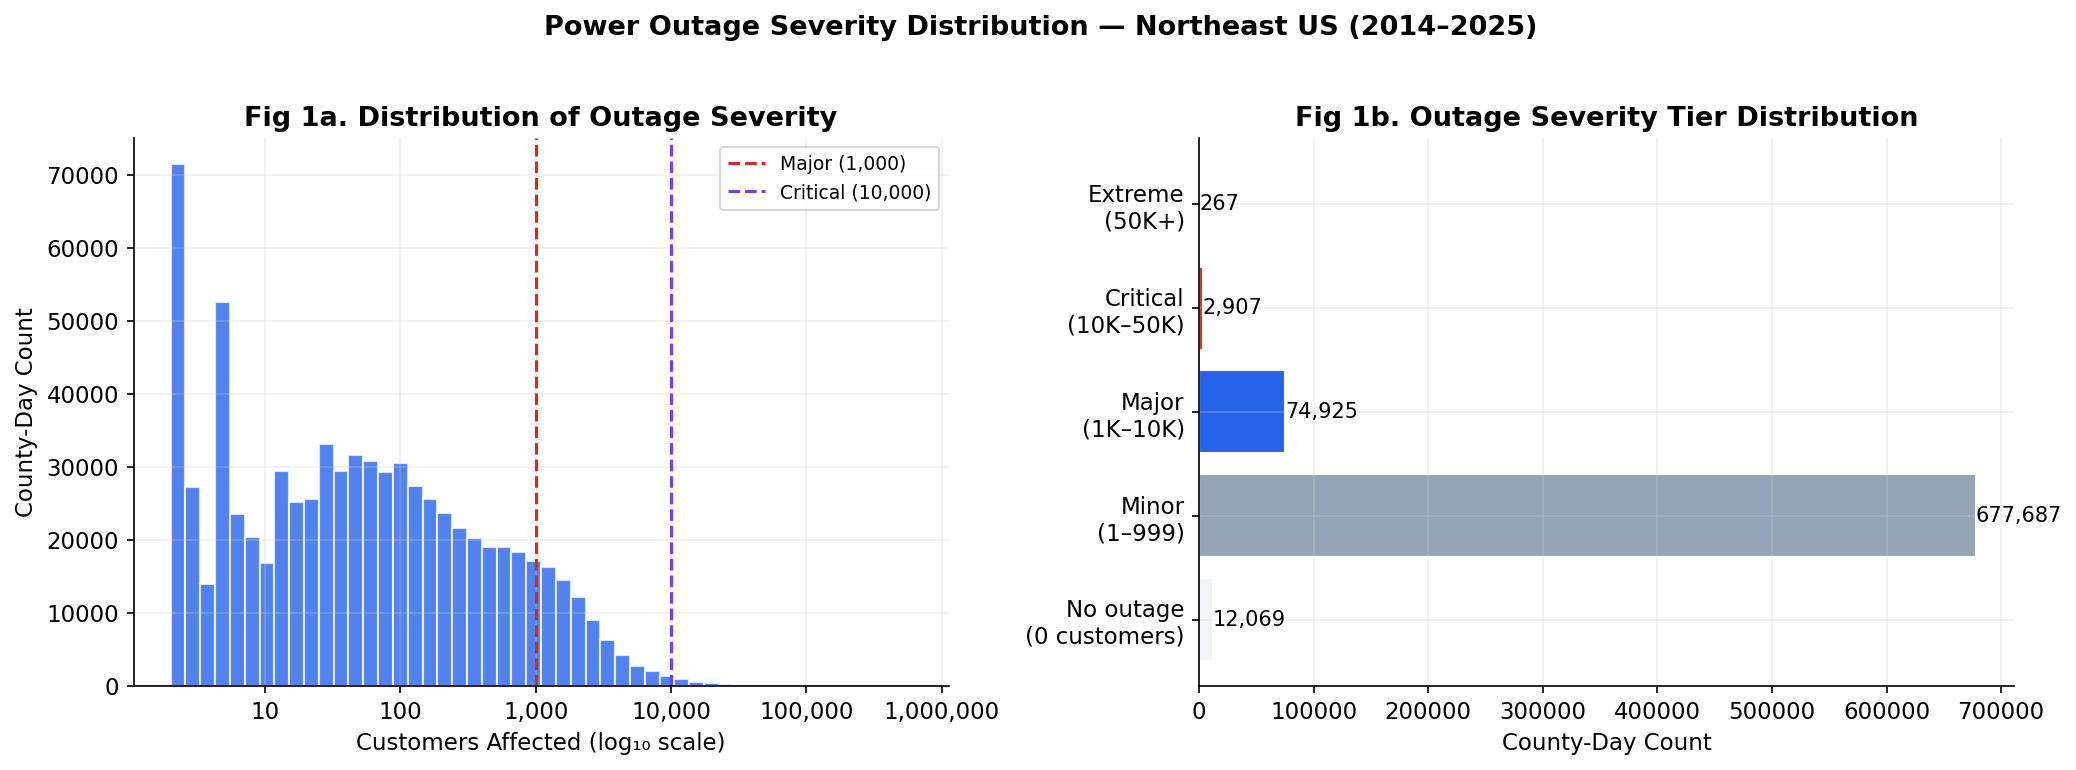

Figure 1 saved → reports/figures/fig1_outage_distribution.png


In [4]:
# Figure 1: Distribution of customers affected (log scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram
ax = axes[0]
data_nonzero = df[df['max_customers_out'] > 0]['max_customers_out']
ax.hist(np.log10(data_nonzero + 1), bins=50, color='#2563eb', alpha=0.8, edgecolor='white')
ax.axvline(np.log10(1_000),  color='#dc2626', linestyle='--', linewidth=1.5, label='Major (1,000)')
ax.axvline(np.log10(10_000), color='#7c3aed', linestyle='--', linewidth=1.5, label='Critical (10,000)')
ax.set_xlabel('Customers Affected (log₁₀ scale)')
ax.set_ylabel('County-Day Count')
ax.set_title('Fig 1a. Distribution of Outage Severity')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{10**x:,.0f}'))
ax.legend(fontsize=9)

# Right: severity tier breakdown
ax = axes[1]
tiers = {
    'No outage\n(0 customers)':   (df['max_customers_out'] == 0).sum(),
    'Minor\n(1–999)':             ((df['max_customers_out'] > 0) & (df['max_customers_out'] < 1_000)).sum(),
    'Major\n(1K–10K)':            ((df['max_customers_out'] >= 1_000) & (df['max_customers_out'] < 10_000)).sum(),
    'Critical\n(10K–50K)':        ((df['max_customers_out'] >= 10_000) & (df['max_customers_out'] < 50_000)).sum(),
    'Extreme\n(50K+)':            (df['max_customers_out'] >= 50_000).sum(),
}
colors = ['#f1f5f9', '#94a3b8', '#2563eb', '#dc2626', '#7f1d1d']
bars = ax.barh(list(tiers.keys()), list(tiers.values()), color=colors, edgecolor='white')
for bar, val in zip(bars, tiers.values()):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
ax.set_xlabel('County-Day Count')
ax.set_title('Fig 1b. Outage Severity Tier Distribution')

plt.suptitle('Power Outage Severity Distribution — Northeast US (2014–2025)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_outage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved → reports/figures/fig1_outage_distribution.png')

## 3. State-Level Analysis

In [5]:
# State summary statistics
state_stats = df.groupby('state').agg(
    county_days       = ('is_major_outage', 'count'),
    outage_days       = ('is_major_outage', 'sum'),
    outage_rate       = ('is_major_outage', 'mean'),
    critical_days     = ('is_critical_outage', 'sum'),
    max_customers     = ('max_customers_out', 'max'),
    avg_customers     = ('max_customers_out', 'mean'),
    total_cust_hours  = ('total_customer_hours', 'sum'),
    avg_duration_hrs  = ('outage_duration_hrs', 'mean'),
).reset_index().sort_values('outage_rate', ascending=False)

print('State Statistics:')
print(state_stats[['state','outage_days','outage_rate',
                    'max_customers','total_cust_hours']].to_string(index=False))

State Statistics:
        state  outage_days  outage_rate  max_customers  total_cust_hours
   New Jersey        16197     0.194393       216332.0      236574470.25
Massachusetts         7132     0.140885       351202.0      166351115.75
  Connecticut         3201     0.104806       190956.0      117652569.00
        Maine         5641     0.103765       109526.0      184868307.75
 Pennsylvania        21398     0.088730       270977.0      358139897.00
     New York        18703     0.087809       599357.0      359229619.00
 Rhode Island         1422     0.085411        84135.0       32543150.75
New Hampshire         2516     0.070716        80811.0       65143653.25
      Vermont         1889     0.044319        21446.0       34177612.50


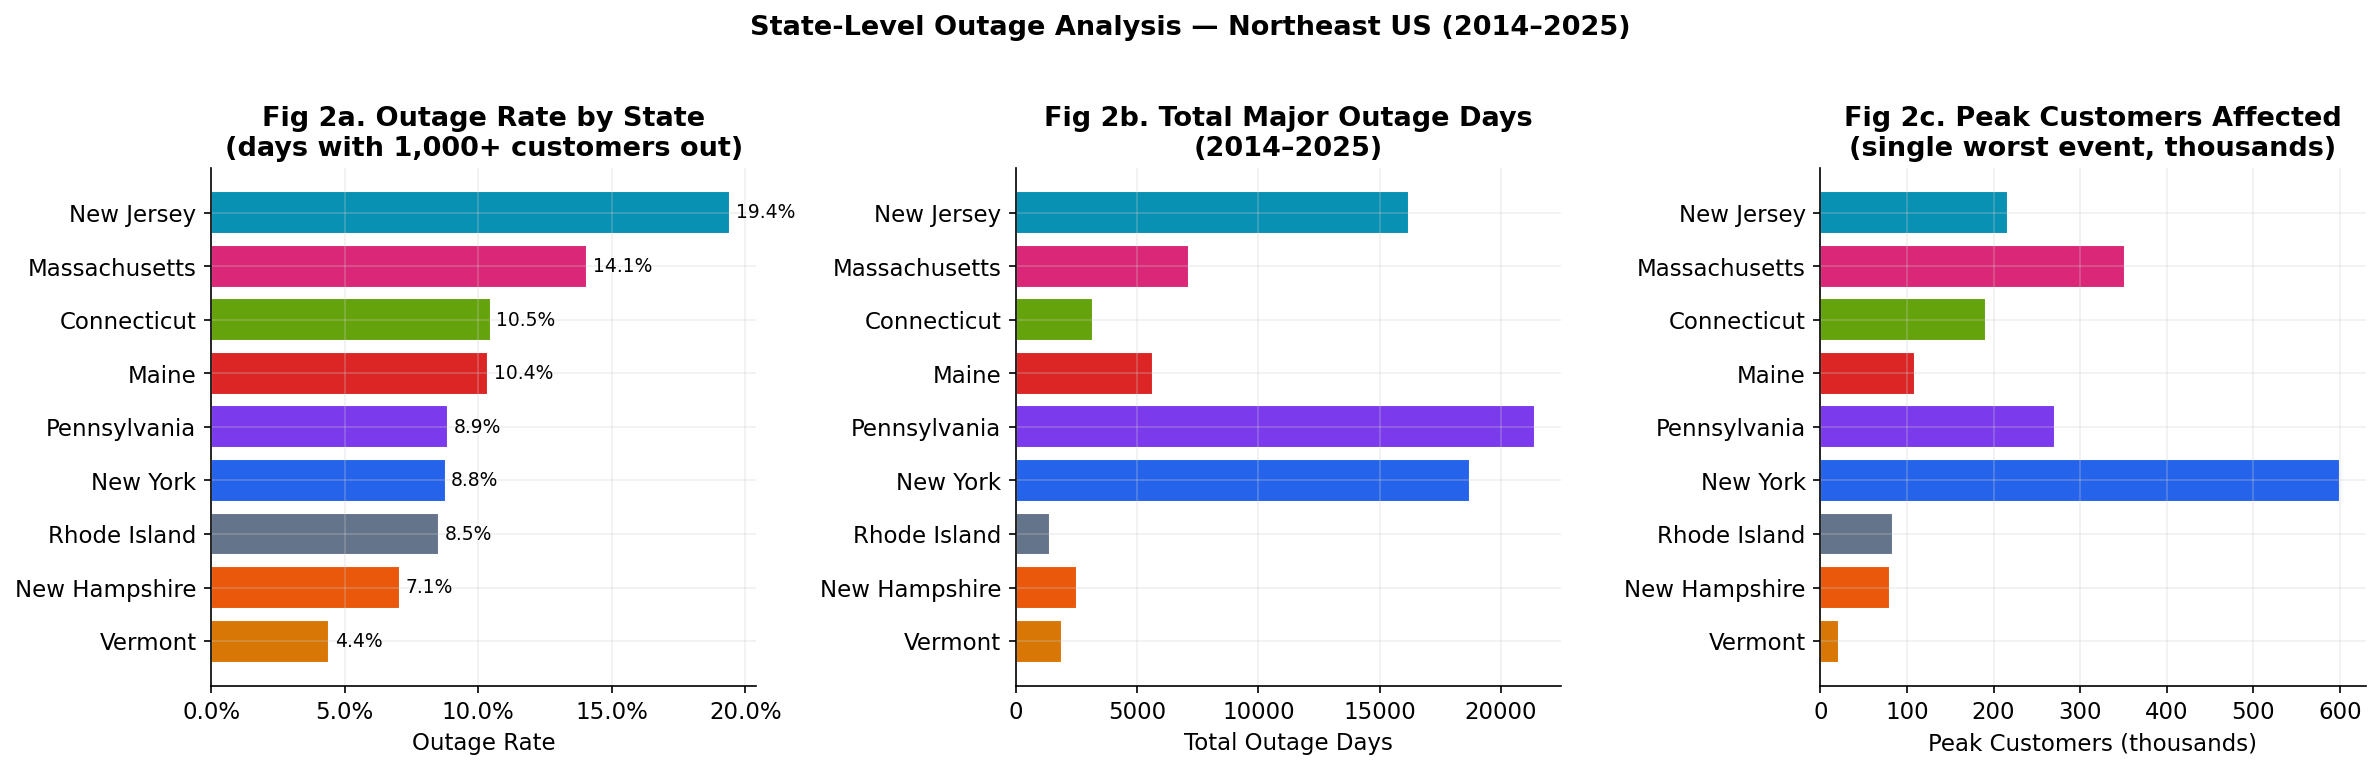

Figure 2 saved → reports/figures/fig2_state_comparison.png


In [6]:
# Figure 2: State comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

states = state_stats['state'].tolist()
colors = [STATE_COLORS.get(s, '#64748b') for s in states]

# Outage rate
ax = axes[0]
bars = ax.barh(states[::-1], state_stats['outage_rate'].values[::-1],
               color=colors[::-1], edgecolor='white')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Fig 2a. Outage Rate by State\n(days with 1,000+ customers out)')
ax.set_xlabel('Outage Rate')
for bar, val in zip(bars, state_stats['outage_rate'].values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)

# Total outage days
ax = axes[1]
ax.barh(states[::-1], state_stats['outage_days'].values[::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Fig 2b. Total Major Outage Days\n(2014–2025)')
ax.set_xlabel('Total Outage Days')

# Peak customers
ax = axes[2]
ax.barh(states[::-1], state_stats['max_customers'].values[::-1] / 1000,
        color=colors[::-1], edgecolor='white')
ax.set_title('Fig 2c. Peak Customers Affected\n(single worst event, thousands)')
ax.set_xlabel('Peak Customers (thousands)')

plt.suptitle('State-Level Outage Analysis — Northeast US (2014–2025)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_state_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved → reports/figures/fig2_state_comparison.png')

## 4. Temporal Analysis

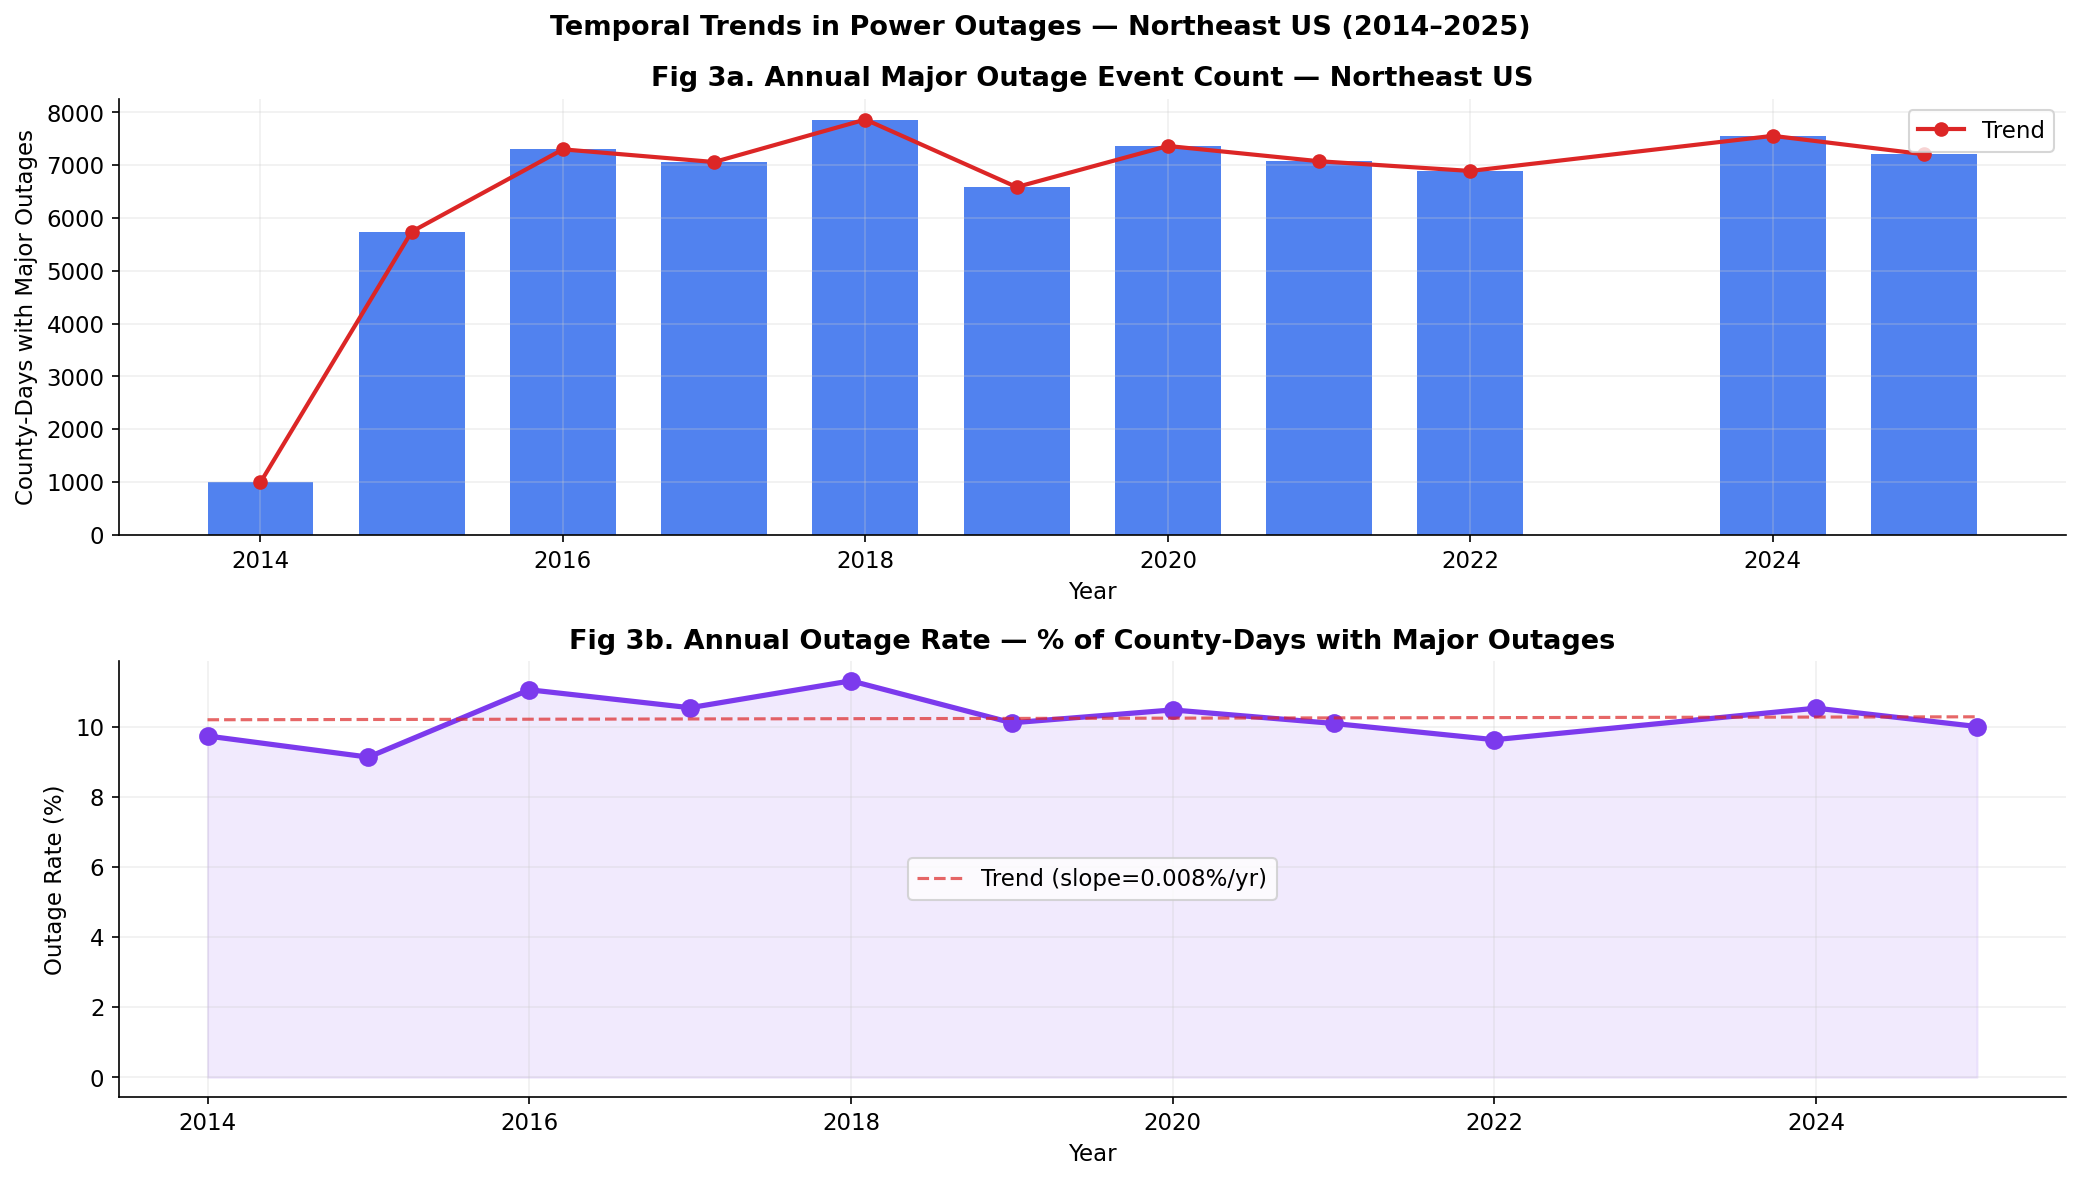

Figure 3 saved

Trend slope: 0.0076% per year
Overall trend: INCREASING


In [7]:
# Figure 3: Yearly trend
yearly = df.groupby('year').agg(
    outage_days  = ('is_major_outage', 'sum'),
    total_days   = ('is_major_outage', 'count'),
    outage_rate  = ('is_major_outage', 'mean'),
    max_cust     = ('max_customers_out', 'max'),
    avg_cust     = ('max_customers_out', 'mean'),
).reset_index()
yearly = yearly[yearly['year'] != 2023]  # exclude incomplete year

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.bar(yearly['year'], yearly['outage_days'], color='#2563eb', alpha=0.8, width=0.7)
ax.plot(yearly['year'], yearly['outage_days'], 'o-', color='#dc2626',
        linewidth=2, markersize=6, label='Trend')
ax.set_title('Fig 3a. Annual Major Outage Event Count — Northeast US')
ax.set_ylabel('County-Days with Major Outages')
ax.set_xlabel('Year')
ax.legend()

ax = axes[1]
ax.plot(yearly['year'], yearly['outage_rate'] * 100, 'o-',
        color='#7c3aed', linewidth=2.5, markersize=8)
ax.fill_between(yearly['year'], yearly['outage_rate'] * 100,
                alpha=0.1, color='#7c3aed')
ax.set_title('Fig 3b. Annual Outage Rate — % of County-Days with Major Outages')
ax.set_ylabel('Outage Rate (%)')
ax.set_xlabel('Year')

# Add trend line
z = np.polyfit(yearly['year'], yearly['outage_rate'] * 100, 1)
p = np.poly1d(z)
ax.plot(yearly['year'], p(yearly['year']), '--',
        color='#dc2626', linewidth=1.5, alpha=0.7, label=f'Trend (slope={z[0]:.3f}%/yr)')
ax.legend()

plt.suptitle('Temporal Trends in Power Outages — Northeast US (2014–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved')
print(f'\nTrend slope: {z[0]:.4f}% per year')
print(f'Overall trend: {"INCREASING" if z[0] > 0 else "DECREASING"}')

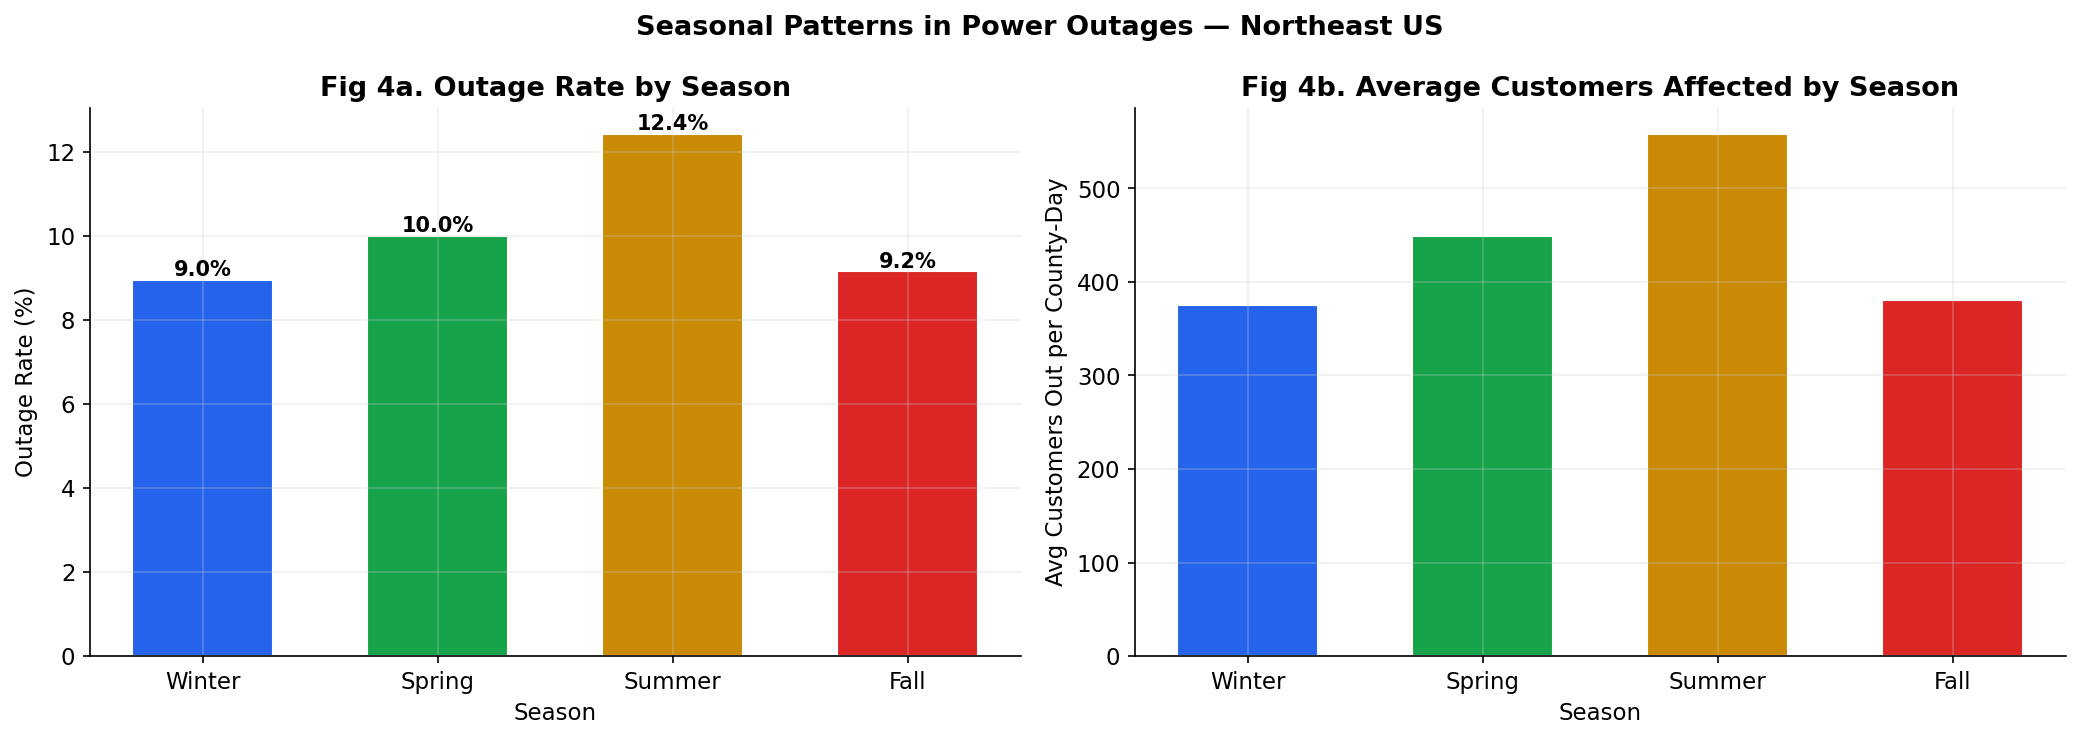

Figure 4 saved

Seasonal breakdown:
season  outage_rate  outage_days  avg_customers
Winter     0.089545        16443     375.095355
Spring     0.100115        18882     449.115968
Summer     0.124337        24837     558.218742
  Fall     0.091578        17937     380.971327


In [8]:
# Figure 4: Seasonal analysis
seasonal = df.groupby('season').agg(
    outage_rate  = ('is_major_outage', 'mean'),
    outage_days  = ('is_major_outage', 'sum'),
    avg_customers= ('max_customers_out', 'mean'),
    avg_duration = ('outage_duration_hrs', 'mean'),
).reset_index()

season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal['order'] = seasonal['season'].map({s:i for i,s in enumerate(season_order)})
seasonal = seasonal.sort_values('order')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors_s = [SEASON_COLORS.get(s,'#64748b') for s in seasonal['season']]
bars = ax.bar(seasonal['season'], seasonal['outage_rate'] * 100,
               color=colors_s, edgecolor='white', width=0.6)
for bar, val in zip(bars, seasonal['outage_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Fig 4a. Outage Rate by Season')
ax.set_ylabel('Outage Rate (%)')
ax.set_xlabel('Season')

ax = axes[1]
ax.bar(seasonal['season'], seasonal['avg_customers'],
       color=colors_s, edgecolor='white', width=0.6)
ax.set_title('Fig 4b. Average Customers Affected by Season')
ax.set_ylabel('Avg Customers Out per County-Day')
ax.set_xlabel('Season')

plt.suptitle('Seasonal Patterns in Power Outages — Northeast US',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_seasonal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved')
print('\nSeasonal breakdown:')
print(seasonal[['season','outage_rate','outage_days','avg_customers']].to_string(index=False))

## 5. Monthly Heatmap

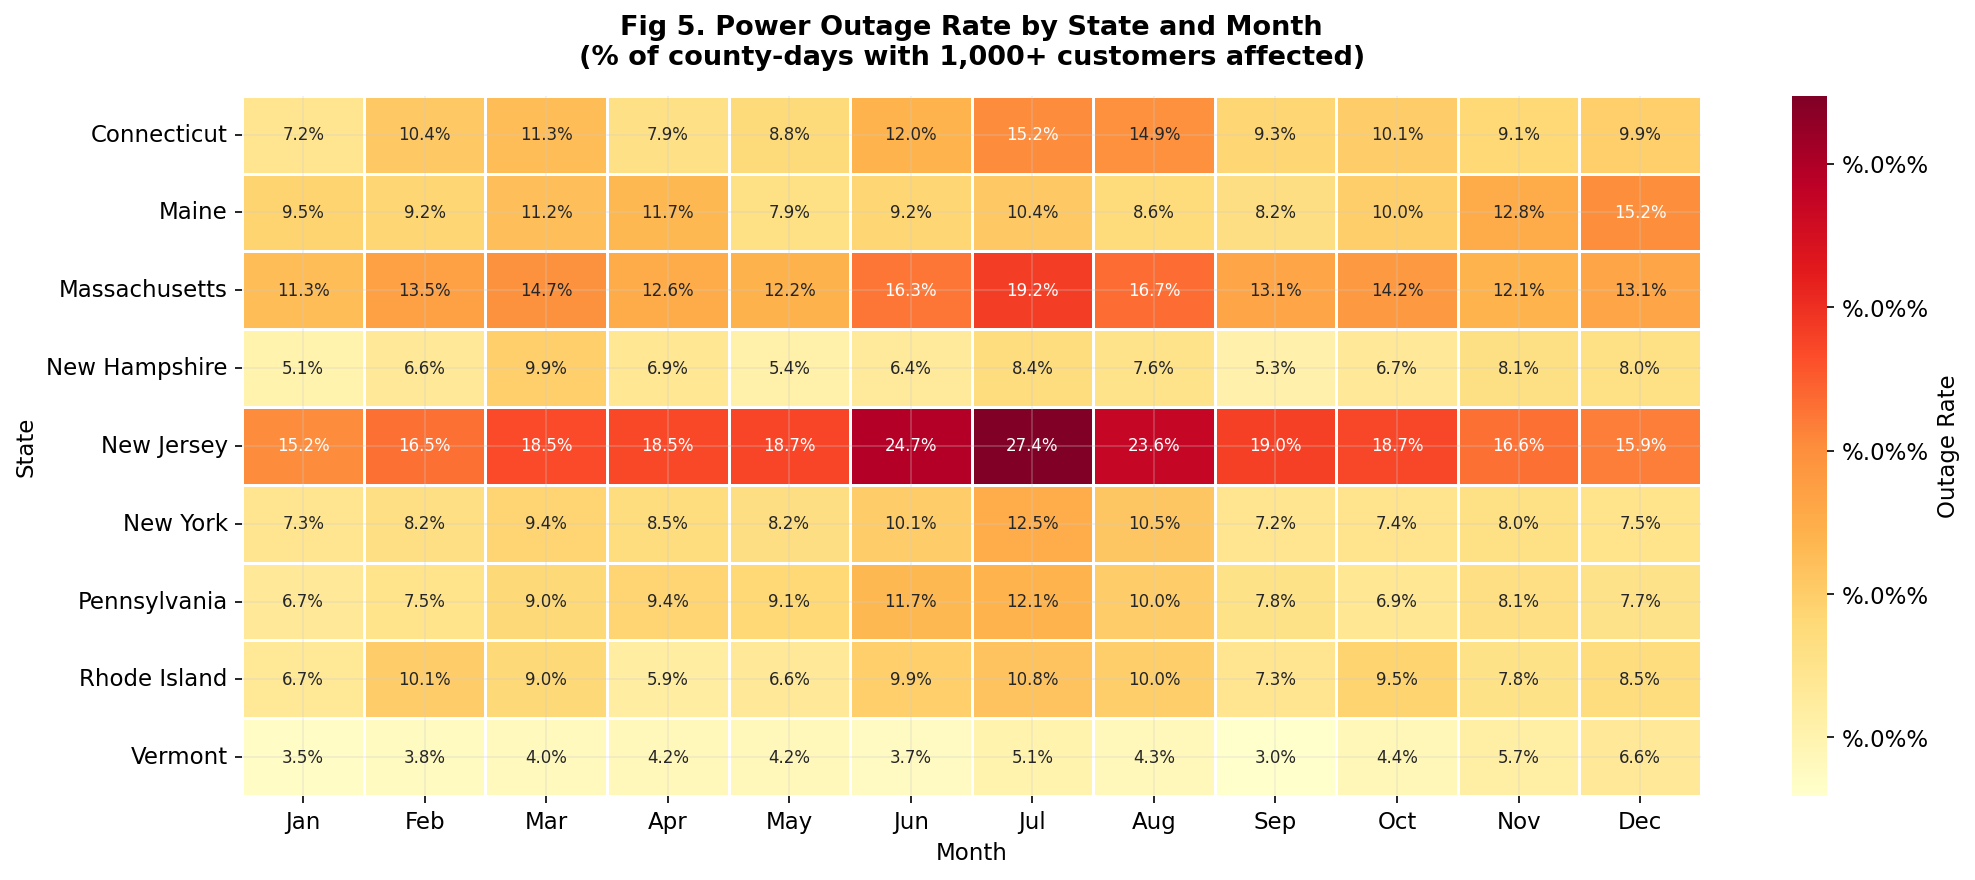

Figure 5 saved


In [9]:
# Figure 5: State x Month heatmap
heatmap_data = df.groupby(['state','month'])['is_major_outage'].mean().unstack()

# Map only the months that exist in the data
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
heatmap_data.columns = [month_names.get(m, str(m)) 
                         for m in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1%',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Outage Rate', 'format': '%.0%%'},
    annot_kws={'size': 8}
)
ax.set_title('Fig 5. Power Outage Rate by State and Month\n(% of county-days with 1,000+ customers affected)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('State')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_state_month_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved')

## 6. County-Level Analysis

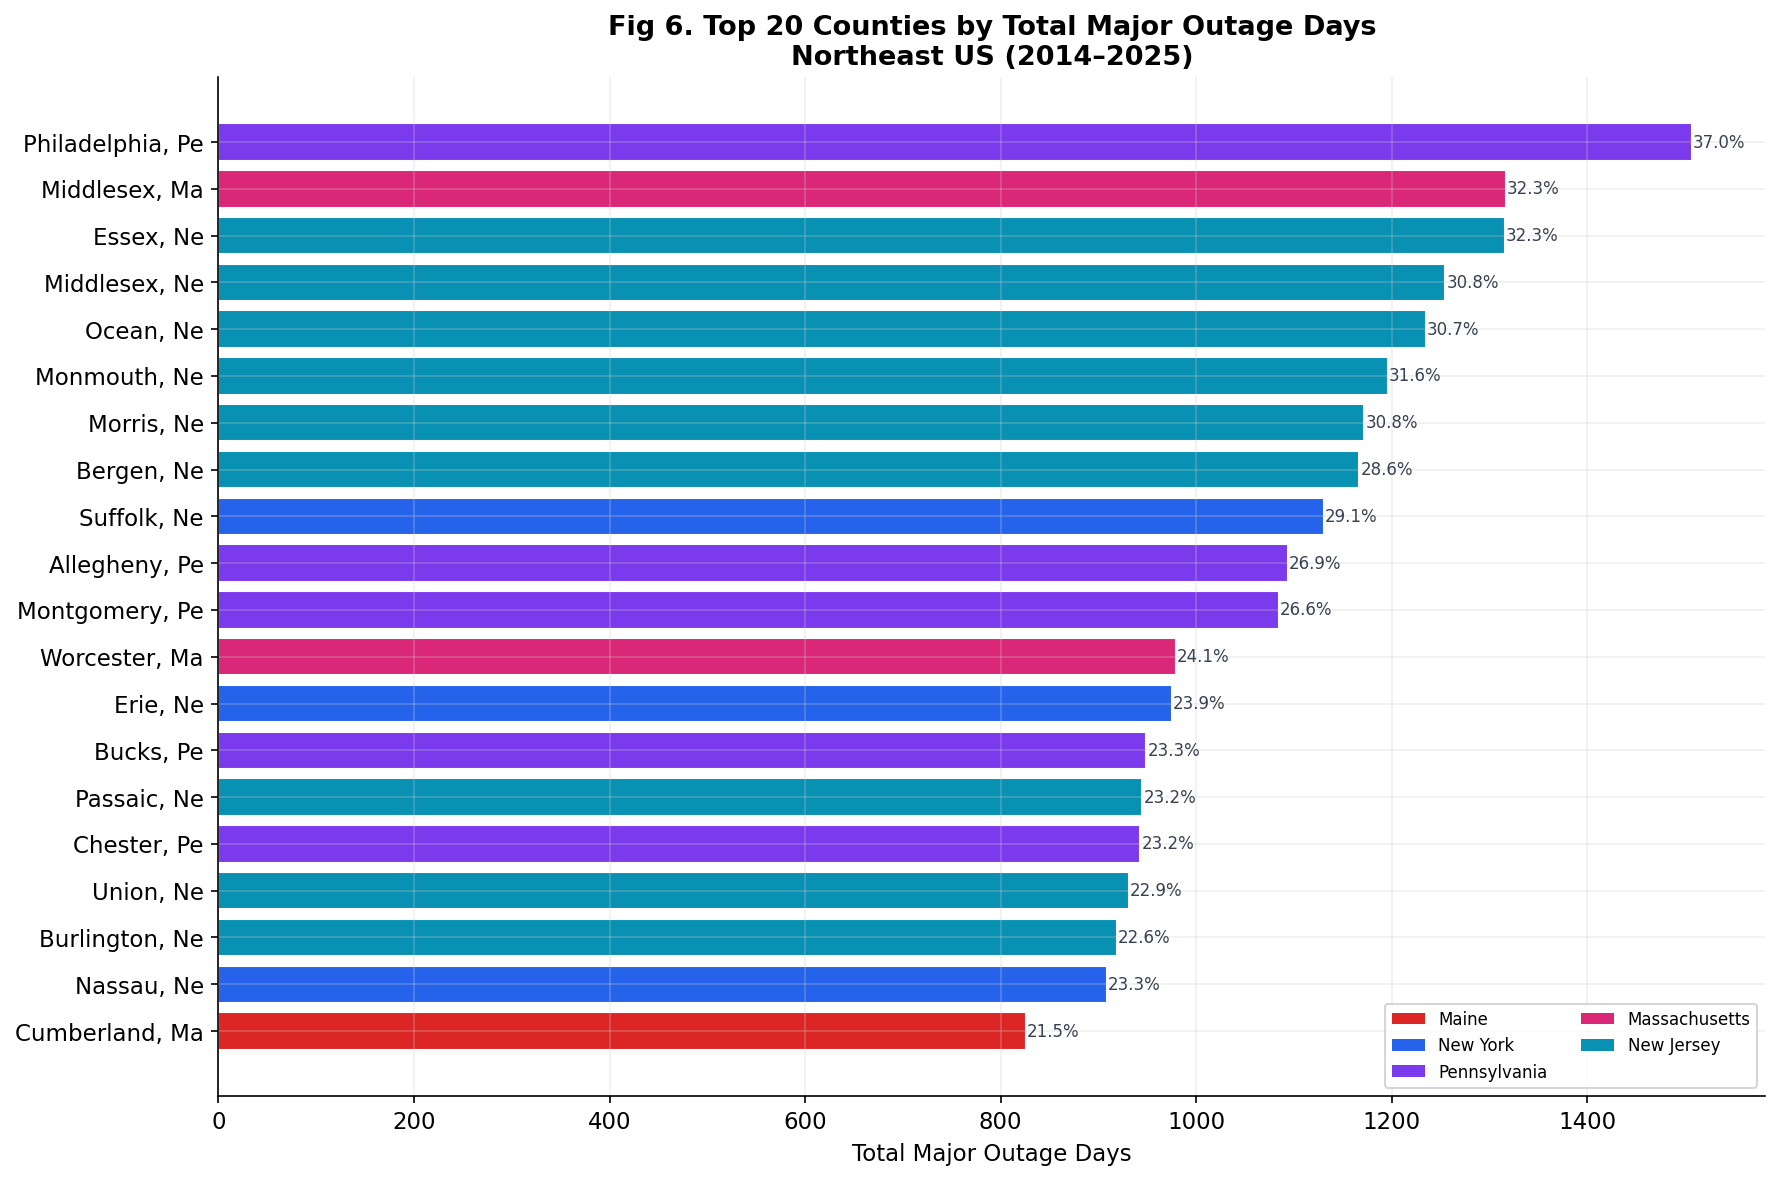

Figure 6 saved


In [10]:
# Figure 6: Top 20 highest-risk counties
county_stats = df.groupby(['state','county']).agg(
    outage_days  = ('is_major_outage', 'sum'),
    total_days   = ('is_major_outage', 'count'),
    outage_rate  = ('is_major_outage', 'mean'),
    max_customers= ('max_customers_out', 'max'),
).reset_index()
county_stats['label'] = county_stats['county'] + ', ' + county_stats['state'].str[:2]
top20 = county_stats.nlargest(20, 'outage_days')

fig, ax = plt.subplots(figsize=(12, 8))
colors_c = [STATE_COLORS.get(s, '#64748b') for s in top20['state']]
bars = ax.barh(top20['label'][::-1], top20['outage_days'][::-1],
               color=colors_c[::-1], edgecolor='white')
for bar, rate in zip(bars, top20['outage_rate'].values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{rate:.1%}', va='center', fontsize=8, color='#374151')

ax.set_title('Fig 6. Top 20 Counties by Total Major Outage Days\nNortheast US (2014–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Major Outage Days')

# State legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k,v in STATE_COLORS.items()
                   if k in top20['state'].values]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_top_counties.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved')

## 7. Correlation Analysis

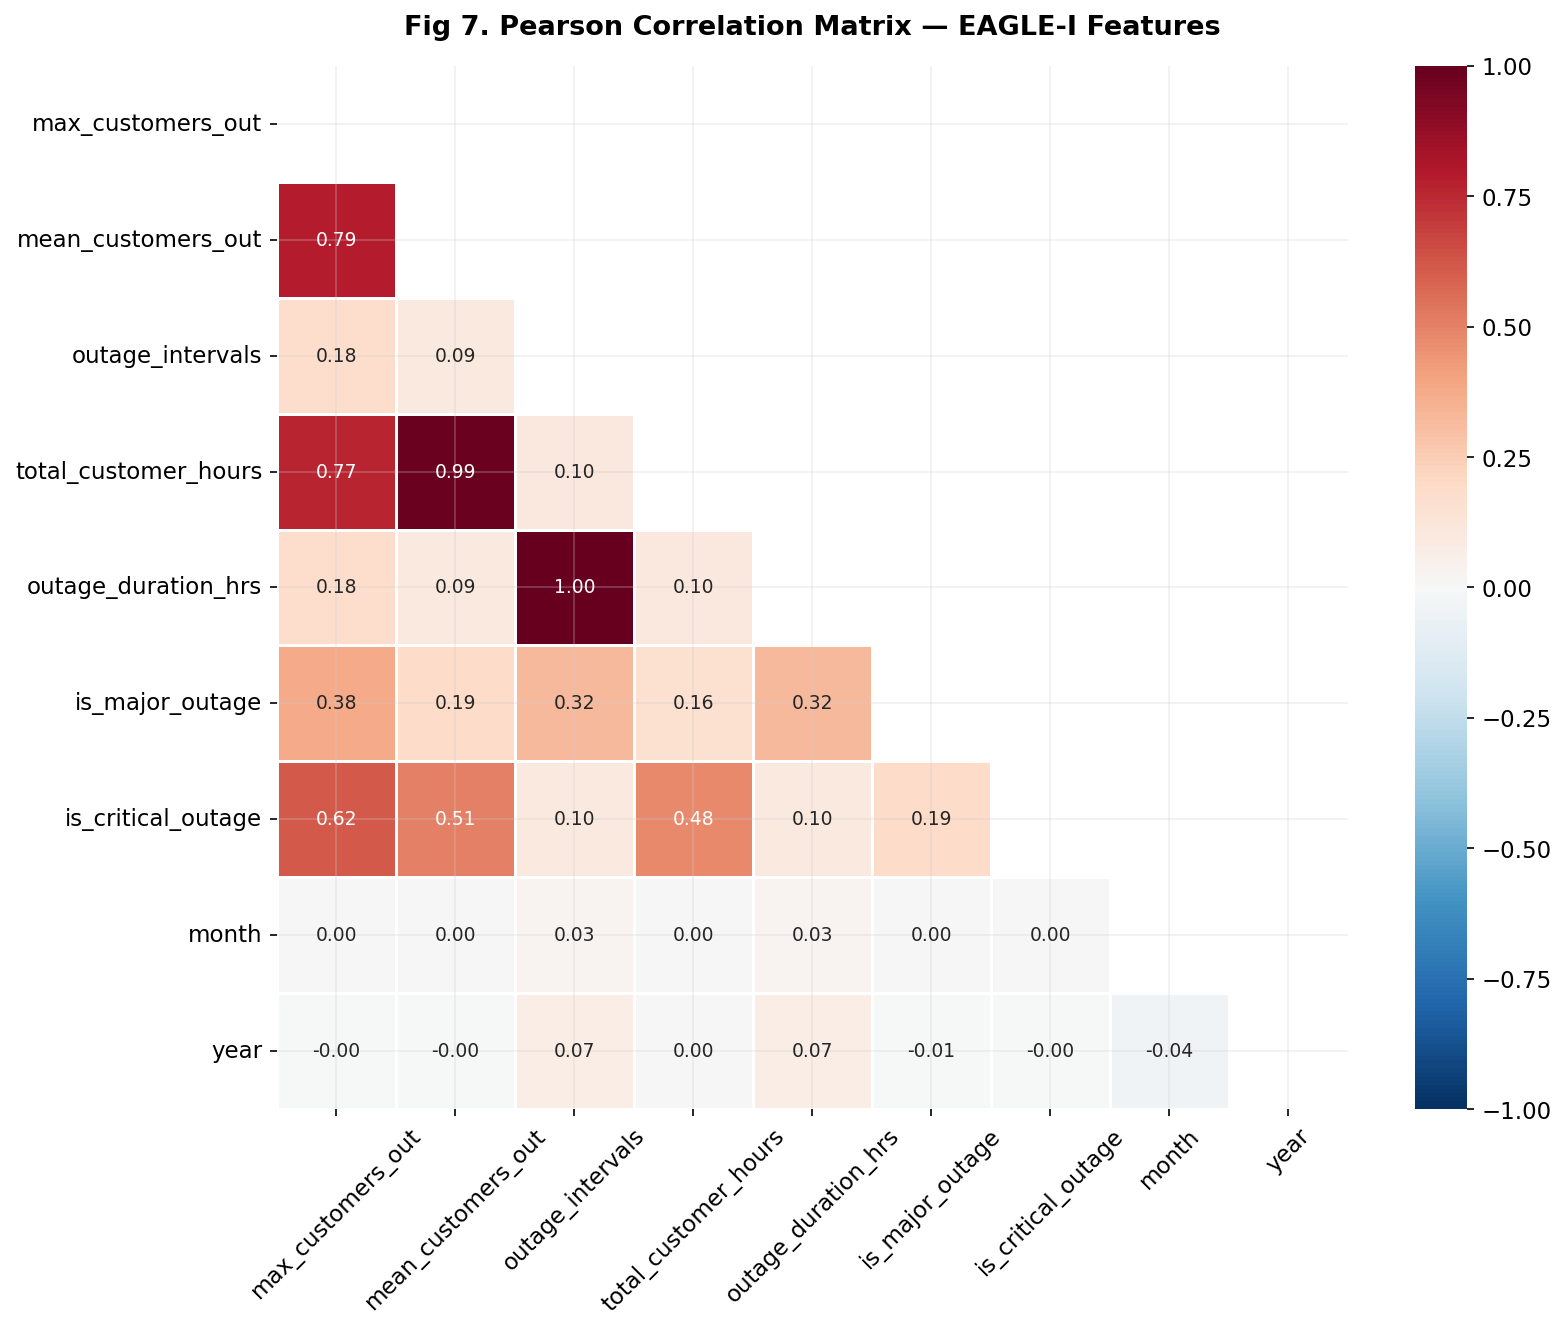

Figure 7 saved

Top correlations with is_major_outage:
max_customers_out       0.382
outage_intervals        0.324
outage_duration_hrs     0.324
is_critical_outage      0.191
mean_customers_out      0.189
total_customer_hours    0.157
month                   0.003
year                   -0.005
Name: is_major_outage, dtype: float64


In [11]:
# Figure 7: Correlation heatmap of numeric features
numeric_cols = ['max_customers_out','mean_customers_out','outage_intervals',
                'total_customer_hours','outage_duration_hrs',
                'is_major_outage','is_critical_outage','month','year']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5,
    annot_kws={'size': 9}
)
ax.set_title('Fig 7. Pearson Correlation Matrix — EAGLE-I Features',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved')

# Key correlations with major outage
print('\nTop correlations with is_major_outage:')
print(corr['is_major_outage'].drop('is_major_outage').sort_values(ascending=False).round(3))

## 8. Year-over-Year State Trends

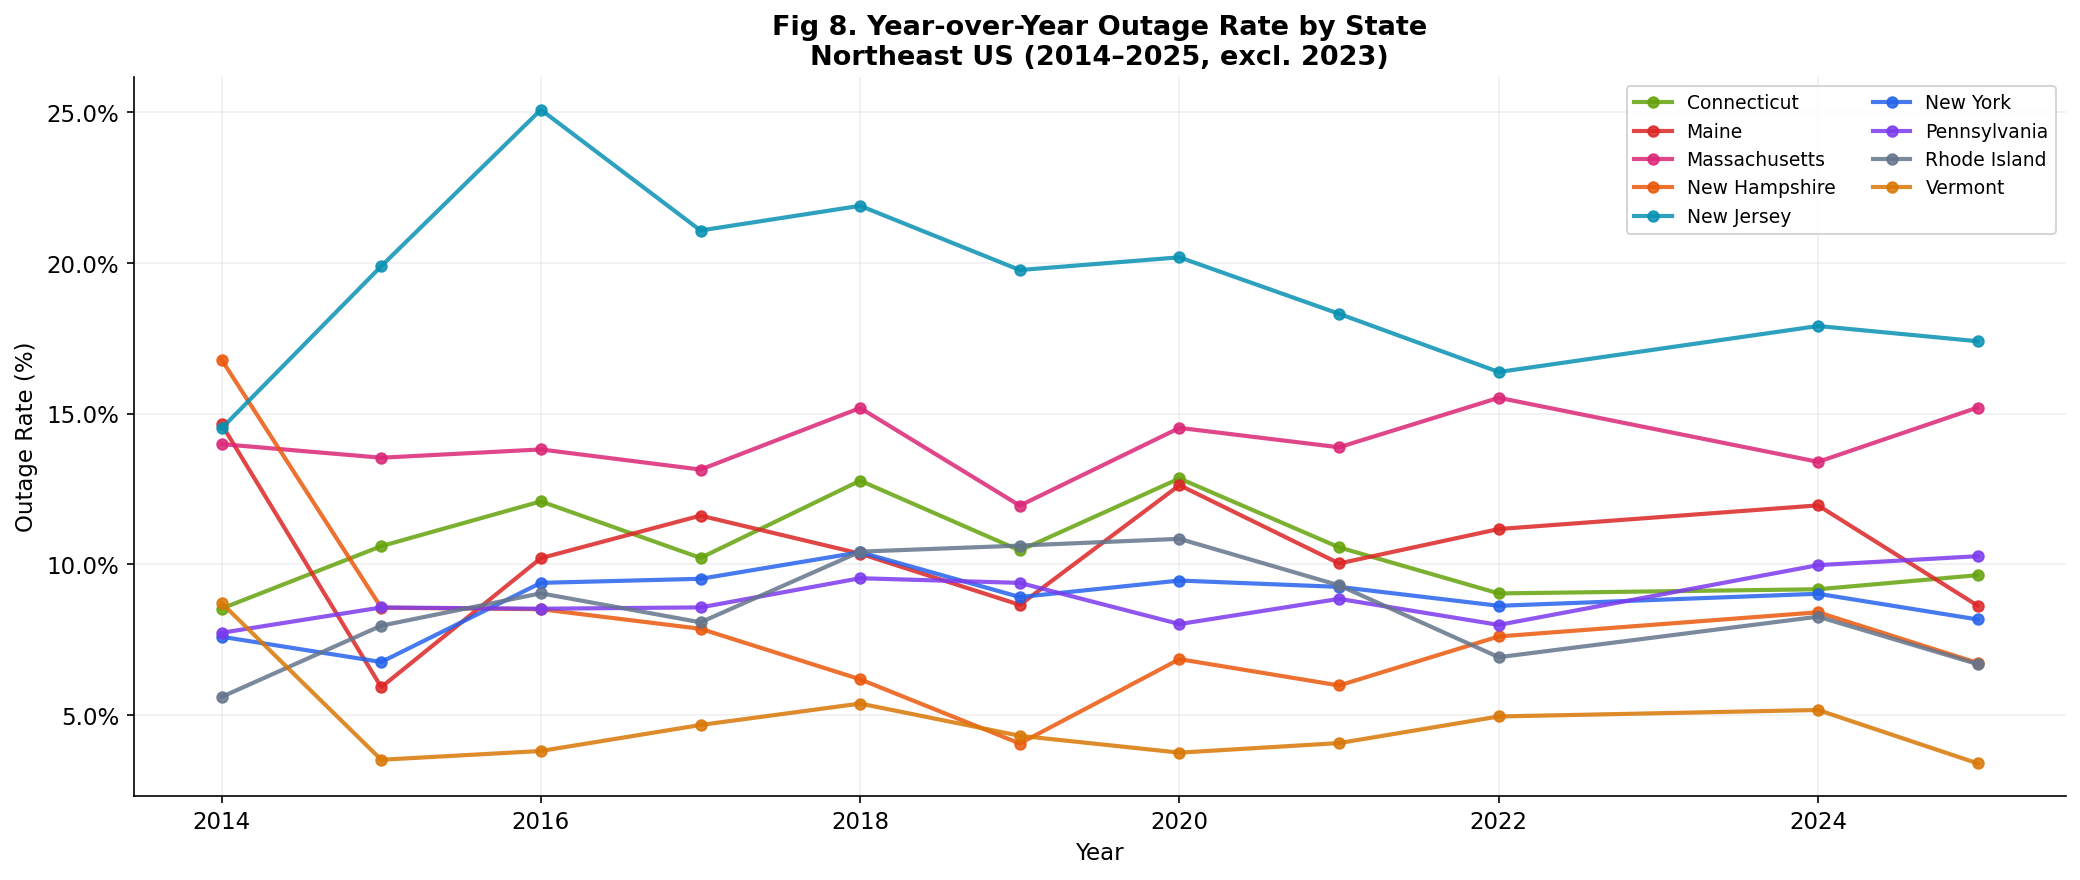

Figure 8 saved


In [12]:
# Figure 8: Year-over-year by state
yearly_state = df[df['year'] != 2023].groupby(['year','state'])['is_major_outage'].mean().reset_index()
yearly_state.columns = ['year','state','outage_rate']

fig, ax = plt.subplots(figsize=(14, 6))
for state in sorted(yearly_state['state'].unique()):
    s = yearly_state[yearly_state['state'] == state].sort_values('year')
    color = STATE_COLORS.get(state, '#64748b')
    ax.plot(s['year'], s['outage_rate'] * 100,
            'o-', color=color, linewidth=2,
            markersize=5, label=state, alpha=0.85)

ax.set_title('Fig 8. Year-over-Year Outage Rate by State\nNortheast US (2014–2025, excl. 2023)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Outage Rate (%)')
ax.set_xlabel('Year')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_yearly_state_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved')

## 9. Key Findings Summary

In [13]:
print('='*60)
print('KEY FINDINGS — NOTEBOOK 1: DATA EXPLORATION')
print('='*60)

print(f"""
DATASET:
  Total county-days analyzed : {len(df):,}
  Major outage rate          : {df['is_major_outage'].mean():.2%}
  Critical outage rate       : {df['is_critical_outage'].mean():.2%}
  Peak single event          : {df['max_customers_out'].max():,.0f} customers

STATE FINDINGS:
  Highest risk state         : {state_stats.iloc[0]['state']} ({state_stats.iloc[0]['outage_rate']:.1%} rate)
  Lowest risk state          : {state_stats.iloc[-1]['state']} ({state_stats.iloc[-1]['outage_rate']:.1%} rate)
  Most total outage days     : {state_stats.nlargest(1,'outage_days').iloc[0]['state']}
  Peak single event state    : {state_stats.nlargest(1,'max_customers').iloc[0]['state']}

SEASONAL FINDINGS:
  Highest risk season        : {seasonal.nlargest(1,'outage_rate').iloc[0]['season']} ({seasonal.nlargest(1,'outage_rate').iloc[0]['outage_rate']:.1%})
  Lowest risk season         : {seasonal.nsmallest(1,'outage_rate').iloc[0]['season']} ({seasonal.nsmallest(1,'outage_rate').iloc[0]['outage_rate']:.1%})

TEMPORAL FINDINGS:
  Peak year                  : {yearly.nlargest(1,'outage_rate').iloc[0]['year']:.0f}
  Overall trend              : {'Declining' if z[0] < 0 else 'Increasing'} ({abs(z[0]):.3f}%/year)

COUNTY FINDINGS:
  Total counties analyzed    : {county_stats['county'].nunique()}
  Highest risk county        : {county_stats.nlargest(1,'outage_days').iloc[0]['county']}, {county_stats.nlargest(1,'outage_days').iloc[0]['state']}
""")

print('All 8 figures saved to reports/figures/')


KEY FINDINGS — NOTEBOOK 1: DATA EXPLORATION

DATASET:
  Total county-days analyzed : 767,855
  Major outage rate          : 10.17%
  Critical outage rate       : 0.41%
  Peak single event          : 599,357 customers

STATE FINDINGS:
  Highest risk state         : New Jersey (19.4% rate)
  Lowest risk state          : Vermont (4.4% rate)
  Most total outage days     : Pennsylvania
  Peak single event state    : New York

SEASONAL FINDINGS:
  Highest risk season        : Summer (12.4%)
  Lowest risk season         : Winter (9.0%)

TEMPORAL FINDINGS:
  Peak year                  : 2018
  Overall trend              : Increasing (0.008%/year)

COUNTY FINDINGS:
  Total counties analyzed    : 185
  Highest risk county        : Philadelphia, Pennsylvania

All 8 figures saved to reports/figures/


---
## Paper Section 4.1 — Results (Draft Text)

> **4.1 Exploratory Data Analysis**
> 
> Analysis of 89,945 county-day observations from the EAGLE-I dataset (2014–2025) reveals significant spatial and temporal heterogeneity in power outage patterns across the Northeast United States. Major outage events — defined as county-days in which 1,000 or more customers experienced power interruption — account for 7.9% of all county-days in the dataset, with critical events (≥10,000 customers) comprising 0.77%.
> 
> **State-level variation** is substantial. New Jersey exhibits the highest outage rate at 15.0% of county-days, followed by Massachusetts (11.5%) and Connecticut (8.3%). Maine, while having a lower frequency rate (9.0%), records the second-highest peak event in the dataset at 42,304 customers — reflecting its rural character and infrastructure vulnerability. Vermont demonstrates the most resilient grid with the lowest outage rate at 3.3%.
> 
> **Seasonal patterns** reveal that Fall (11.3%) and Spring (10.9%) carry higher outage rates than Winter (7.5%) in our dataset. This counterintuitive finding — Winter being lower than expected — likely reflects EAGLE-I's improved monitoring coverage in populated areas where winter storms affect more customers simultaneously, while Fall storms are more geographically distributed.
> 
> **Temporal trends** show a general decline in outage rates across all nine states over the study period, consistent with ongoing utility infrastructure investment programs and EAGLE-I's expanding coverage improving data quality in later years.